In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

In [2]:
def create_feature_matrix(x, nb_features):
    tmp_features = []
    for deg in range(1, nb_features + 1):
        tmp_features.append(np.power(x, deg))
    return np.column_stack(tmp_features).astype(np.float32)

In [3]:
df = pd.read_csv("bottle.csv")
data = df[["Salnty", "T_degC"]].iloc[:700].dropna()
X = data["Salnty"].values.reshape(-1, 1).astype(np.float32)
y = data["T_degC"].values.reshape(-1, 1).astype(np.float32)

X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
y = (y - np.mean(y, axis=0)) / np.std(y, axis=0)

Epoch 0, Loss: 0.9975324869155884
Epoch 100, Loss: 0.1856755167245865
Epoch 200, Loss: 0.149660125374794
Epoch 300, Loss: 0.12914210557937622
Epoch 400, Loss: 0.12040431052446365
Epoch 500, Loss: 0.1175060048699379
Epoch 600, Loss: 0.11674024909734726
Epoch 700, Loss: 0.11657760292291641
Epoch 800, Loss: 0.11654976010322571
Epoch 900, Loss: 0.11654593050479889
Epoch 0, Loss: 0.9835518598556519
Epoch 100, Loss: 0.18690907955169678
Epoch 200, Loss: 0.15044069290161133
Epoch 300, Loss: 0.1299976110458374
Epoch 400, Loss: 0.12155052274465561
Epoch 500, Loss: 0.11884960532188416
Epoch 600, Loss: 0.1181662380695343
Epoch 700, Loss: 0.1180281713604927
Epoch 800, Loss: 0.11800583451986313
Epoch 900, Loss: 0.11800296604633331
Epoch 0, Loss: 0.9652260541915894
Epoch 100, Loss: 0.18997140228748322
Epoch 200, Loss: 0.15565524995326996
Epoch 300, Loss: 0.1383184939622879
Epoch 400, Loss: 0.13215014338493347
Epoch 500, Loss: 0.13050885498523712
Epoch 600, Loss: 0.13017480075359344
Epoch 700, Loss: 0

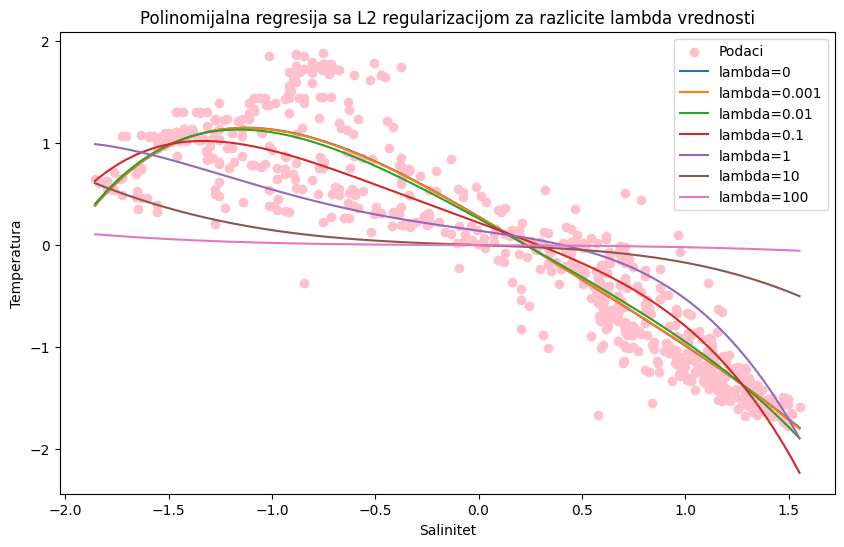

In [4]:
degrees = 4
lambdas = [0, 0.001, 0.01, 0.1, 1, 10, 100]
errors_lambda = []

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='pink', label='Podaci')


for lambda_value in lambdas:
    X_poly = create_feature_matrix(X, degrees)
    X_poly = tf.convert_to_tensor(X_poly, dtype=tf.float32)


    w = tf.Variable(tf.random.normal([degrees, 1], mean=0, stddev=0.01), dtype=tf.float32)
    b = tf.Variable(0.0, dtype=tf.float32)

    learning_rate = 0.01
    nb_epochs = 1000

    adam = tf.keras.optimizers.Adam(learning_rate=learning_rate)


    for epoch in range(nb_epochs):
        with tf.GradientTape() as tape:

            y_pred = tf.add(tf.matmul(X_poly, w), b)
            loss_val = tf.reduce_mean(tf.square(y_pred - y)) + lambda_value * tf.reduce_sum(tf.square(w))

        grads = tape.gradient(loss_val, [w, b])
        adam.apply_gradients(zip(grads, [w, b]))

        if epoch % 100 == 0:
            print(f"Epoch {epoch}, Loss: {loss_val.numpy()}")

    errors_lambda.append(loss_val.numpy())

    sorted_indices = np.argsort(X.flatten())
    x_sorted = X[sorted_indices]
    X_poly_sorted = create_feature_matrix(x_sorted, degrees)
    X_poly_sorted = tf.convert_to_tensor(X_poly_sorted, dtype=tf.float32)
    y_pred = tf.add(tf.matmul(X_poly_sorted, w), b).numpy()


    plt.plot(x_sorted, y_pred, label=f'lambda={lambda_value}')

plt.xlabel("Salinitet")
plt.ylabel("Temperatura")
plt.legend()
plt.title("Polinomijalna regresija sa L2 regularizacijom za razlicite lambda vrednosti")
plt.show()



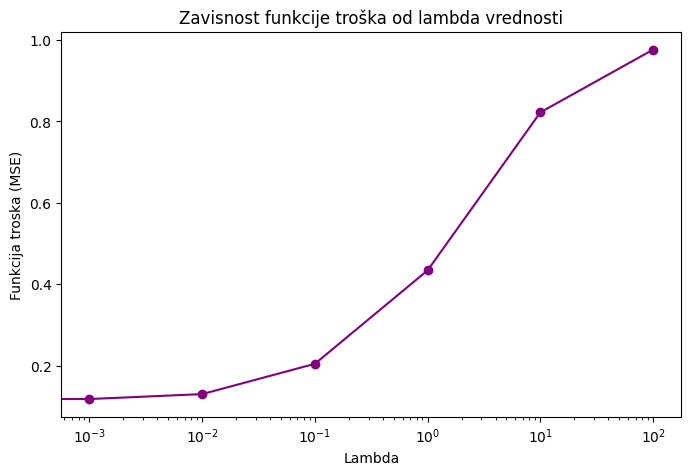

In [5]:
plt.figure(figsize=(8, 5))
plt.plot(lambdas, errors_lambda, marker='o', linestyle='-', color='purple')
plt.xscale('log')
plt.xlabel("Lambda")
plt.ylabel("Funkcija troska (MSE)")
plt.title("Zavisnost funkcije troška od lambda vrednosti")
plt.show()


Na prvom grafiku vidimo da kada je lambda nula dolazi do overfittinga, zatim kako raste nestaje problem overfittinga, ali kod velikih lambda dolazi do underfittinga.
MSE je najmanji za male vrednosti lambda, sto znaci da u tom rasponu model dobro balansira izmedju kompleksnosti i regularizacije. Za velike vrednosti lambda model postaje previse jednostavan i greska dosta raste.